In [16]:
print("Outfit Recommender V7 - Metadata + Style-Aware Hybrid System")

Outfit Recommender V7 - Metadata + Style-Aware Hybrid System


In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

In [18]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("MobileNetV2 loaded successfully")

C:\Users\ousama\AppData\Local\Temp\ipykernel_2116\2553550147.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


MobileNetV2 loaded successfully


In [19]:
IMAGE_FOLDER = "../images"

files = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

print("Number of images:", len(files))
print(files[:5])

Number of images: 95
['#outfits #fashion #summer #summerstyle.jpg', '#StylishWoman.jpg', '14+ Inspiring Minimalist Fashion Ideas For Men.jpg', '20 Western Fall Outfits for Women in 2025 That Are Equal Parts Cute and Comfy.webp', "2024 Men's Streetwear Guide_ 20 Trendsetting Styles & Fashion Tips - Elevate Your Wardrobe!.jpg"]


In [20]:
metadata = {
    "antonio medugno.jpg": {
        "gender": "male",
        "style": "minimal",
        "season": "summer",
        "occasion": "casual"
    },

    "#outfits #fashion #summer #summerstyle.jpg": {
        "gender": "male",
        "style": "minimal",
        "season": "summer",
        "occasion": "casual"
    },

    "30 Effortlessly Chic Outfits to Copy for Summer.jpg": {
        "gender": "female",
        "style": "minimal",
        "season": "summer",
        "occasion": "casual"
    },

    "Trendy Streetwear Outfit Ideas for Men _.jpg": {
        "gender": "female",
        "style": "streetwear",
        "season": "summer",
        "occasion": "casual"
    },

    "download (1).webp": {
        "gender": "male",
        "style": "streetwear",
        "season": "winter",
        "occasion": "casual"
    }
}

In [21]:
def extract_deep_features(img_path, model):

    img = image.load_img(img_path, target_size=(224, 224))

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    features = model.predict(img_array, verbose=0)

    return features.flatten()

In [22]:
def extract_manual_features(img_path, n_colors=3):

    img = Image.open(img_path).convert("RGB")
    img = img.resize((100, 100))

    img_array = np.array(img)

    flat_pixels = img_array.reshape(-1, 3)

    # Dominant colors
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    kmeans.fit(flat_pixels)

    colors = kmeans.cluster_centers_.flatten()

    # Brightness
    brightness = np.mean(flat_pixels)

    # Contrast
    contrast = np.std(flat_pixels)

    # Grayscale
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    # Edge density
    edges = cv2.Canny(gray, 100, 200)

    edge_density = np.sum(edges > 0) / edges.size

    # Texture
    texture = np.std(gray)

    manual_features = np.concatenate([
        colors,
        [brightness, contrast, edge_density, texture]
    ])

    return manual_features

In [23]:
deep_features_list = []
manual_features_list = []

for file in files:

    path = os.path.join(IMAGE_FOLDER, file)

    deep_features = extract_deep_features(path, base_model)

    manual_features = extract_manual_features(path)

    deep_features_list.append(deep_features)

    manual_features_list.append(manual_features)

deep_features_array = np.array(deep_features_list)
manual_features_array = np.array(manual_features_list)

print("Deep features shape:", deep_features_array.shape)
print("Manual features shape:", manual_features_array.shape)

Deep features shape: (95, 1280)
Manual features shape: (95, 13)


In [24]:
deep_scaler = StandardScaler()
manual_scaler = StandardScaler()

deep_scaled = deep_scaler.fit_transform(deep_features_array)

manual_scaled = manual_scaler.fit_transform(manual_features_array)

In [28]:
combined_features = np.concatenate([
    deep_scaled,
    manual_scaled
], axis=1)

print("Combined features shape:", combined_features.shape)

Combined features shape: (95, 1293)


In [29]:
def metadata_match(input_meta, target_meta):

    score = 0

    if input_meta["gender"] == target_meta["gender"]:
        score += 1

    if input_meta["style"] == target_meta["style"]:
        score += 1

    if input_meta["season"] == target_meta["season"]:
        score += 1

    if input_meta["occasion"] == target_meta["occasion"]:
        score += 1

    return score

In [30]:
def recommend_v7(input_image, top_n=5):

    input_file = os.path.basename(input_image)

    if input_file not in metadata:
        print("Metadata not found for input image")
        return

    input_meta = metadata[input_file]

    input_deep = extract_deep_features(input_image, base_model)

    input_manual = extract_manual_features(input_image)

    input_deep_scaled = deep_scaler.transform([input_deep])

    input_manual_scaled = manual_scaler.transform([input_manual])

    input_combined = np.concatenate([
        input_deep_scaled,
        input_manual_scaled
    ], axis=1)

    similarities = cosine_similarity(
        input_combined,
        combined_features
    )[0]

    ranked = []

    for index, sim in enumerate(similarities):

        file = files[index]

        if file == input_file:
            continue

        if file not in metadata:
            continue

        target_meta = metadata[file]

        meta_score = metadata_match(input_meta, target_meta)

        final_score = sim + (meta_score * 0.1)

        ranked.append((file, final_score))

    ranked = sorted(ranked, key=lambda x: x[1], reverse=True)

    for file, score in ranked[:top_n]:

        img_path = os.path.join(IMAGE_FOLDER, file)

        img = Image.open(img_path).convert("RGB")

        print(file)
        print("Final Score:", round(score, 3))
        print("Metadata:", metadata[file])

        plt.imshow(img)
        plt.axis("off")
        plt.show()

#outfits #fashion #summer #summerstyle.jpg
Final Score: 0.623
Metadata: {'gender': 'male', 'style': 'minimal', 'season': 'summer', 'occasion': 'casual'}


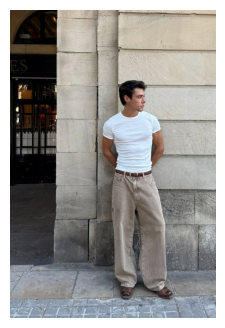

30 Effortlessly Chic Outfits to Copy for Summer.jpg
Final Score: 0.486
Metadata: {'gender': 'female', 'style': 'minimal', 'season': 'summer', 'occasion': 'casual'}


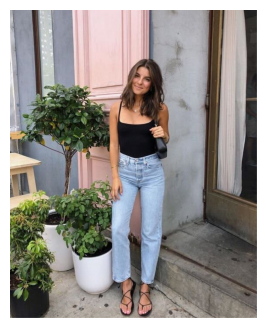

download (1).webp
Final Score: 0.359
Metadata: {'gender': 'male', 'style': 'streetwear', 'season': 'winter', 'occasion': 'casual'}


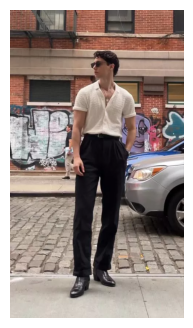

In [31]:
selected_image = r"C:\Users\ousama\Downloads\Fashion Color Analyzer\images\antonio medugno.jpg"

recommend_v7(selected_image, top_n=5)